# Task 3 — CycleGAN Official Evaluation

This notebook is tailored to your trained CycleGAN.

- Project folder: `/app/task3_gan`
- Checkpoint: `checkpoints/best_cycle_checkpoint.pt`
- `G_AB`: photo → Monet
- `G_BA`: Monet → photo
- Evaluation size: 300 images in each direction

It generates the two prediction folders required by the supplied evaluation script, calculates directional FID and MiFID, averages both directions, and saves `submission.csv`.

Run the cells from top to bottom. This notebook does not train or modify the model checkpoint.

## Step 1 — Install and import the required packages

The RTX GPU is used for image generation and Inception feature extraction. The final FID matrix calculation is performed by SciPy on the CPU.

In [1]:
%pip install -q scipy pillow tqdm pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import scipy.linalg
from scipy.spatial.distance import cosine

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms.functional import to_pil_image
from torchvision import models

SEED = 5775
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 5090


## Step 2 — Set and verify your paths

No path change is needed if your trained project is still stored at `/app/task3_gan`.

In [3]:
# ------------------------------------------------------------
# Dataset and experiment paths
# ------------------------------------------------------------

DATA_PROJECT_ROOT = Path(
    "/app/task3_gan"
)

EXPERIMENT_ROOT = Path(
    "/app/task3_gan_resizeconv_multiscale_ema"
)

REAL_MONET = (
    DATA_PROJECT_ROOT
    / "data"
    / "monet_jpg"
)

REAL_PHOTO = (
    DATA_PROJECT_ROOT
    / "data"
    / "photo_jpg"
)

CHECKPOINT_PATH = (
    EXPERIMENT_ROOT
    / "checkpoints"
    / "best_cycle_checkpoint.pt"
)


# ------------------------------------------------------------
# Separate evaluation folder for this checkpoint
# ------------------------------------------------------------

EVALUATION_ROOT = (
    EXPERIMENT_ROOT
    / "official_evaluation_300"
    / CHECKPOINT_PATH.stem
)

GEN_A2B = (
    EVALUATION_ROOT
    / "pred_A2B_monet_to_photo"
)

GEN_B2A = (
    EVALUATION_ROOT
    / "pred_B2A_photo_to_monet"
)


# ------------------------------------------------------------
# Evaluation settings
# ------------------------------------------------------------

N_EVAL = 300
GENERATION_BATCH_SIZE = 16
METRIC_BATCH_SIZE = 32
NUM_WORKERS = 0

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
}


def list_images(folder):
    return sorted(
        path
        for path in folder.iterdir()
        if (
            path.is_file()
            and path.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    )


# ------------------------------------------------------------
# Verify paths
# ------------------------------------------------------------

for folder in [REAL_MONET, REAL_PHOTO]:
    if not folder.is_dir():
        raise FileNotFoundError(
            f"Missing data folder: {folder}"
        )

if not CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        f"Missing checkpoint: {CHECKPOINT_PATH}"
    )


# ------------------------------------------------------------
# Load image paths
# ------------------------------------------------------------

real_monet_paths = list_images(REAL_MONET)
real_photo_paths = list_images(REAL_PHOTO)

if (
    len(real_monet_paths) < N_EVAL
    or len(real_photo_paths) < N_EVAL
):
    raise ValueError(
        "At least 300 images are required "
        "in each real-image folder."
    )


# ------------------------------------------------------------
# Create evaluation folders
# ------------------------------------------------------------

GEN_A2B.mkdir(
    parents=True,
    exist_ok=True,
)

GEN_B2A.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("Checkpoint:", CHECKPOINT_PATH)
print("Real Monet images:", len(real_monet_paths))
print("Real photo images:", len(real_photo_paths))
print("Evaluation output:", EVALUATION_ROOT)

Checkpoint: /app/task3_gan_resizeconv_multiscale_ema/checkpoints/best_cycle_checkpoint.pt
Real Monet images: 300
Real photo images: 7038
Evaluation output: /app/task3_gan_resizeconv_multiscale_ema/official_evaluation_300/best_cycle_checkpoint


## Step 3 — Recreate the generator architecture

This is the same 9-residual-block generator used during your training.

In [4]:
# ============================================================
# Resize-convolution generator architecture
# ============================================================

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
            ),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),

            nn.ReflectionPad2d(1),
            nn.Conv2d(
                channels,
                channels,
                kernel_size=3,
            ),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, inputs):
        return inputs + self.block(inputs)


class Generator(nn.Module):
    def __init__(
        self,
        input_channels=3,
        output_channels=3,
        num_residual_blocks=9,
    ):
        super().__init__()

        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(
                input_channels,
                64,
                kernel_size=7,
            ),
            nn.InstanceNorm2d(64),
            nn.ReLU(inplace=True),
        ]

        channels = 64

        # Downsampling
        for _ in range(2):
            layers.extend([
                nn.Conv2d(
                    channels,
                    channels * 2,
                    kernel_size=4,
                    stride=2,
                    padding=1,
                ),
                nn.InstanceNorm2d(
                    channels * 2
                ),
                nn.ReLU(inplace=True),
            ])

            channels *= 2

        # Residual blocks
        for _ in range(num_residual_blocks):
            layers.append(
                ResidualBlock(channels)
            )

        # Resize-convolution upsampling
        for _ in range(2):
            layers.extend([
                nn.Upsample(
                    scale_factor=2,
                    mode="nearest",
                ),
                nn.ReflectionPad2d(1),
                nn.Conv2d(
                    channels,
                    channels // 2,
                    kernel_size=3,
                    stride=1,
                    padding=0,
                ),
                nn.InstanceNorm2d(
                    channels // 2
                ),
                nn.ReLU(inplace=True),
            ])

            channels //= 2

        layers.extend([
            nn.ReflectionPad2d(3),
            nn.Conv2d(
                channels,
                output_channels,
                kernel_size=7,
            ),
            nn.Tanh(),
        ])

        self.model = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.model(inputs)


# ------------------------------------------------------------
# Create generators
# ------------------------------------------------------------

G_AB = Generator().to(device)
G_BA = Generator().to(device)


# ------------------------------------------------------------
# Load EMA checkpoint weights
# ------------------------------------------------------------

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

G_AB.load_state_dict(
    checkpoint["G_AB_state_dict"]
)

G_BA.load_state_dict(
    checkpoint["G_BA_state_dict"]
)

G_AB.eval()
G_BA.eval()

print(
    "Loaded checkpoint from epoch:",
    checkpoint.get("epoch", "unknown"),
)

print(
    "Uses EMA weights:",
    checkpoint.get("uses_ema", "unknown"),
)

print(
    checkpoint.get(
        "metric_name",
        "saved metric",
    ),
    checkpoint.get(
        "metric_value",
        "not available",
    ),
)

Loaded checkpoint from epoch: 55
Uses EMA weights: True
ema_validation_cycle_loss 0.08211431006590525


## Step 4 — Generate 300 images in each direction

The output names and direction mapping match the supplied evaluation notebook:

- `pred_A2B_monet_to_photo`: generated by `G_BA`
- `pred_B2A_photo_to_monet`: generated by `G_AB`

Only old PNG files inside these two generated-output folders are replaced.

In [5]:
generation_transform = transforms.Compose([
    transforms.Resize(
        (256, 256),
        interpolation=transforms.InterpolationMode.BICUBIC,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5),
    ),
])


class ImagePathDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        return generation_transform(image)


def save_generated_images(model, input_paths, output_folder, description):
    # Prevent old generated files from affecting the new evaluation.
    for old_path in output_folder.glob("*.png"):
        old_path.unlink()

    dataset = ImagePathDataset(input_paths[:N_EVAL])
    loader = DataLoader(
        dataset,
        batch_size=GENERATION_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    image_index = 0
    use_amp = device.type == "cuda"

    with torch.inference_mode():
        for batch in tqdm(loader, desc=description):
            batch = batch.to(device, non_blocking=True)

            with torch.autocast(
                device_type=device.type,
                dtype=torch.bfloat16,
                enabled=use_amp,
            ):
                generated = model(batch)

            generated = generated.float().cpu()
            generated = (generated * 0.5 + 0.5).clamp(0, 1)

            for image in generated:
                output_path = output_folder / f"{image_index:05d}.png"
                to_pil_image(image).save(output_path)
                image_index += 1

    return image_index


# Monet -> photo uses G_BA.
count_a2b = save_generated_images(
    model=G_BA,
    input_paths=real_monet_paths,
    output_folder=GEN_A2B,
    description="Generating Monet -> photo",
)

# Photo -> Monet uses G_AB.
count_b2a = save_generated_images(
    model=G_AB,
    input_paths=real_photo_paths,
    output_folder=GEN_B2A,
    description="Generating photo -> Monet",
)

print("Generated Monet -> photo:", count_a2b)
print("Generated photo -> Monet:", count_b2a)

assert count_a2b == N_EVAL
assert count_b2a == N_EVAL

Generating photo -> Monet: 100%|██████████| 19/19 [00:10<00:00,  1.84it/s]

Generated Monet -> photo: 300
Generated photo -> Monet: 300


## Step 5 — Inspect a few generated images

Check that the direction labels look correct before calculating the metrics.

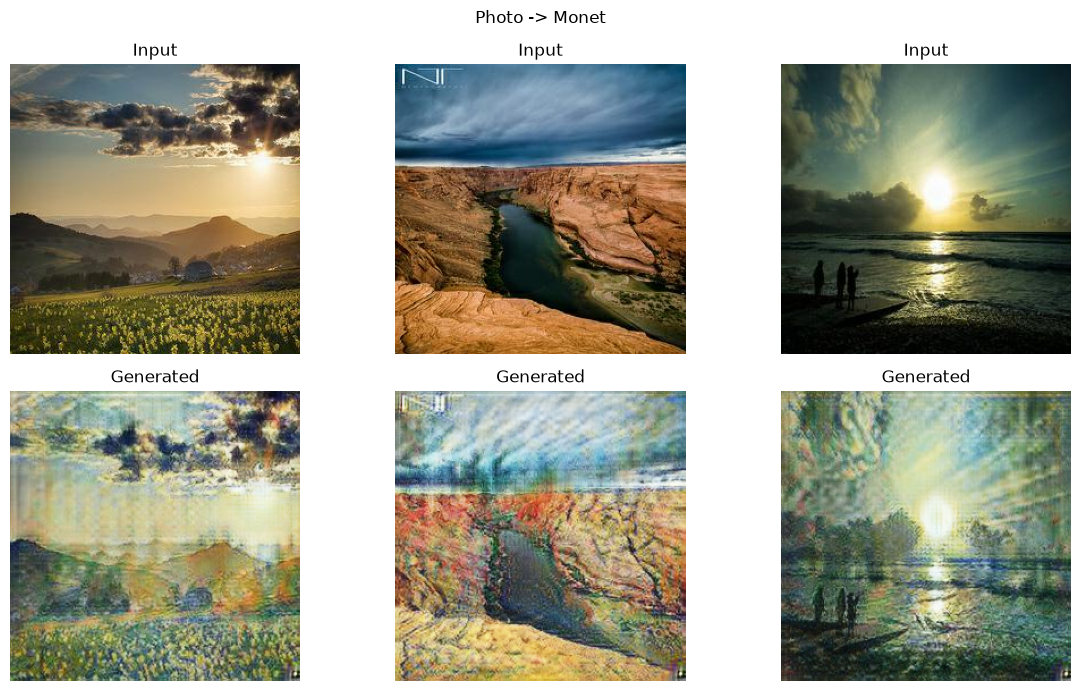

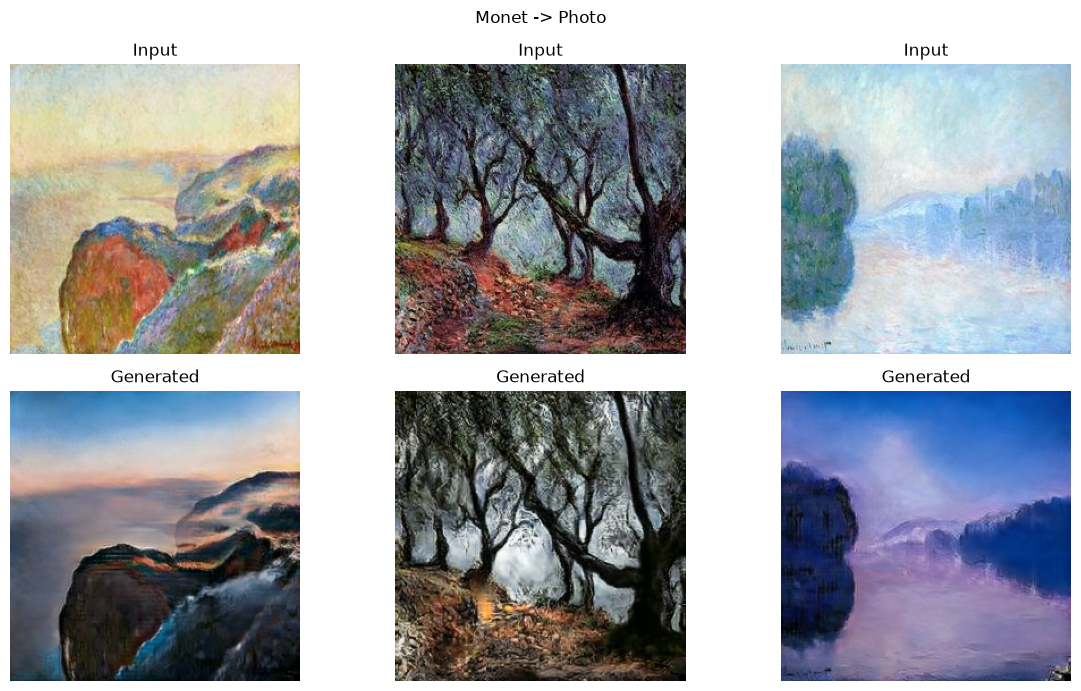

In [6]:
def show_examples(real_paths, generated_folder, title, count=3):
    generated_paths = list_images(generated_folder)
    fig, axes = plt.subplots(2, count, figsize=(4 * count, 7))

    for index in range(count):
        axes[0, index].imshow(Image.open(real_paths[index]).convert("RGB"))
        axes[0, index].set_title("Input")
        axes[1, index].imshow(Image.open(generated_paths[index]).convert("RGB"))
        axes[1, index].set_title("Generated")

        axes[0, index].axis("off")
        axes[1, index].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_examples(real_photo_paths, GEN_B2A, "Photo -> Monet")
show_examples(real_monet_paths, GEN_A2B, "Monet -> Photo")

## Step 6 — Calculate the official FID and MiFID

This section follows the supplied evaluation script. Lower values are better for both metrics.

In [7]:
INCEPTION_TRANSFORM = transforms.Compose([
    transforms.Resize(299),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225),
    ),
])


def get_inception_model():
    model = models.inception_v3(
        weights=models.Inception_V3_Weights.IMAGENET1K_V1,
        transform_input=False,
    )
    model.fc = nn.Identity()
    model = model.to(device)
    model.eval()
    return model


def load_inception_batch(paths):
    images = []
    for path in paths:
        image = Image.open(path).convert("RGB")
        images.append(INCEPTION_TRANSFORM(image))
    return torch.stack(images)


@torch.inference_mode()
def get_activations(model, image_paths, batch_size=32):
    features = []

    for start in tqdm(
        range(0, len(image_paths), batch_size),
        desc="Inception activations",
    ):
        batch_paths = image_paths[start:start + batch_size]
        images = load_inception_batch(batch_paths).to(device)
        batch_features = model(images).float().cpu().numpy()
        features.append(batch_features)

    return np.concatenate(features, axis=0)


def frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    covmean, _ = scipy.linalg.sqrtm(
        sigma1.dot(sigma2),
        disp=False,
    )

    if not np.isfinite(covmean).all():
        offset = np.eye(sigma1.shape[0]) * eps
        covmean = scipy.linalg.sqrtm(
            (sigma1 + offset).dot(sigma2 + offset)
        )

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    difference = mu1 - mu2

    return float(
        difference.dot(difference)
        + np.trace(sigma1 + sigma2 - 2 * covmean)
    )


def calculate_fid_mifid(model, real_paths, generated_paths, batch_size=32):
    real_paths = sorted(real_paths)
    generated_paths = sorted(generated_paths)

    count = min(len(real_paths), len(generated_paths), N_EVAL)
    real_paths = real_paths[:count]
    generated_paths = generated_paths[:count]

    real_activations = get_activations(model, real_paths, batch_size)
    generated_activations = get_activations(model, generated_paths, batch_size)

    real_mean = real_activations.mean(axis=0)
    real_covariance = np.cov(real_activations, rowvar=False)
    generated_mean = generated_activations.mean(axis=0)
    generated_covariance = np.cov(generated_activations, rowvar=False)

    fid = frechet_distance(
        real_mean,
        real_covariance,
        generated_mean,
        generated_covariance,
    )

    cosine_distances = [
        cosine(real_activations[index], generated_activations[index])
        for index in range(count)
    ]
    mifid = float(np.mean(cosine_distances))

    return fid, mifid, count

In [8]:
generated_a2b_paths = list_images(GEN_A2B)
generated_b2a_paths = list_images(GEN_B2A)

print("Counts used by the evaluator:")
print("Real Monet:", min(N_EVAL, len(real_monet_paths)))
print("Generated Monet:", min(N_EVAL, len(generated_b2a_paths)))
print("Real photo:", min(N_EVAL, len(real_photo_paths)))
print("Generated photo:", min(N_EVAL, len(generated_a2b_paths)))

inception_model = get_inception_model()

print("\nEvaluating photo -> Monet")
fid_b2a, mifid_b2a, count_b2a = calculate_fid_mifid(
    model=inception_model,
    real_paths=real_monet_paths,
    generated_paths=generated_b2a_paths,
    batch_size=METRIC_BATCH_SIZE,
)
print(f"Photo -> Monet: FID={fid_b2a:.3f}, MiFID={mifid_b2a:.4f}")

print("\nEvaluating Monet -> photo")
fid_a2b, mifid_a2b, count_a2b = calculate_fid_mifid(
    model=inception_model,
    real_paths=real_photo_paths,
    generated_paths=generated_a2b_paths,
    batch_size=METRIC_BATCH_SIZE,
)
print(f"Monet -> photo: FID={fid_a2b:.3f}, MiFID={mifid_a2b:.4f}")

Counts used by the evaluator:
Real Monet: 300
Generated Monet: 300
Real photo: 300
Generated photo: 300

Evaluating photo -> Monet


Inception activations: 100%|██████████| 10/10 [00:04<00:00,  2.10it/s]
/tmp/ipykernel_20174/1812347060.py:48: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy.linalg.sqrtm(


Photo -> Monet: FID=105.451, MiFID=0.4063

Evaluating Monet -> photo


Inception activations: 100%|██████████| 10/10 [00:04<00:00,  2.08it/s]


Monet -> photo: FID=98.331, MiFID=0.4182


## Step 7 — Save the final submission

The submission uses the average of the two translation directions, exactly as in the provided script.

In [9]:
average_fid = (fid_a2b + fid_b2a) / 2
average_mifid = (mifid_a2b + mifid_b2a) / 2

directional_results = {
    "photo_to_monet": {
        "FID": float(fid_b2a),
        "MiFID": float(mifid_b2a),
        "evaluation_images": int(count_b2a),
    },
    "monet_to_photo": {
        "FID": float(fid_a2b),
        "MiFID": float(mifid_a2b),
        "evaluation_images": int(count_a2b),
    },
    "average": {
        "FID": float(average_fid),
        "MiFID": float(average_mifid),
    },
}

submission = pd.DataFrame([{
    "ID": 1,
    "FID": float(average_fid),
    "MiFID": float(average_mifid),
}])

submission_path = EVALUATION_ROOT / "submission.csv"
results_path = EVALUATION_ROOT / "directional_metrics.json"

# submission.to_csv(submission_path, index=False)

# with open(results_path, "w", encoding="utf-8") as file:
#     json.dump(directional_results, file, indent=4)

print("Directional results:")
display(pd.DataFrame(directional_results).T.round(4))

print("Submission:")
display(submission.round(4))

print("Saved submission:", submission_path)
print("Saved detailed metrics:", results_path)

Directional results:


,FID,MiFID,evaluation_images
photo_to_monet,105.4507,0.4063,300.0
monet_to_photo,98.3306,0.4182,300.0
average,101.8907,0.4123,NaN


Submission:


,ID,FID,MiFID
0,1,101.8907,0.4123


Saved submission: /app/task3_gan_resizeconv_multiscale_ema/official_evaluation_300/best_cycle_checkpoint/submission.csv
Saved detailed metrics: /app/task3_gan_resizeconv_multiscale_ema/official_evaluation_300/best_cycle_checkpoint/directional_metrics.json


100 - 96.2505	0.4067
95 - 96.0607	0.4065
90 - 96.5091	0.4067
85 - 	96.0026	0.4067

60 - 100.8 0.412  80 - 101.1193	0.4097 100 - 100.92	0.4071 40 - 101.73 0.412